# **4. LSTM**

## **4.1. Librerias**

In [1]:
import os
import copy
import random
import optuna

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel, wilcoxon
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf, pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

import geopandas as gpd
from libpysal.weights import Queen
import sys
import time


## **4.2. Configuración Reproducibilidad**

In [2]:
SEEDS = [42, 123, 2024]

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("DEVICE:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("Numpy:", np.__version__)
print("Pandas:", pd.__version__)

DEVICE: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU
Python: 3.10.20 (main, Mar  3 2026, 09:24:47) [GCC 13.3.0]
Torch: 2.11.0+cu130
Numpy: 2.2.6
Pandas: 2.3.3


El entorno de ejecución utiliza PyTorch 2.11 con soporte CUDA 13.0 y una GPU NVIDIA GeForce RTX 5050 Laptop, lo que permite acelerar significativamente el entrenamiento de modelos de deep learning. Además, la configuración de semillas múltiples y versiones recientes de librerías como NumPy y Pandas favorece la reproducibilidad y estabilidad experimental.


In [3]:
def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    torch.use_deterministic_algorithms(True)
    os.environ["PYTHONHASHSEED"] = str(seed)

    print(f"Seed fijada: {seed}")


def seed_worker(worker_id):

    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


g = torch.Generator()

Este código implementa una estrategia exhaustiva de reproducibilidad en experimentos con PyTorch, fijando semillas en random, numpy y torch, además de desactivar optimizaciones no deterministas de CUDA (como cudnn.benchmark) para garantizar resultados consistentes entre ejecuciones. Asimismo, se controla la aleatoriedad en los *data loaders* mediante seed_worker y un generador de PyTorch, asegurando coherencia en el muestreo paralelo de datos.

## **4.3. Carga de Datos & Preprocesamiento**

### **4.3.1. Carga de Datos**

In [4]:
df = pd.read_csv("/home/guirlessa/Dl_Proyecto_Dengue/Bases_Datos/df_full.csv")
df.head()

,departamento,fecha_inicio,ano,semana,casos,casos_mujeres,casos_hombres,casos_rural,casos_urbano,(0_5],...,precip_lag_12,precip_lag_20,temp_c,temp_lag_1,temp_lag_2,temp_lag_3,temp_lag_4,temp_lag_8,temp_lag_12,temp_lag_20
0,Amazonas,2012-01-02,2012,1,0.0,0,0,0,0,0,...,50.983546,39.108242,24.848668,24.890654,24.334752,24.545618,25.345678,25.278160,25.874930,24.364443
1,Amazonas,2012-01-09,2012,2,0.0,0,0,0,0,0,...,61.818291,62.830250,24.729721,24.848668,24.890654,24.334752,24.545618,25.084141,25.495665,24.971798
2,Amazonas,2012-01-16,2012,3,0.0,0,0,0,0,0,...,24.950393,42.988018,24.638674,24.729721,24.848668,24.890654,24.334752,25.751070,25.760539,25.304947
3,Amazonas,2012-01-23,2012,4,0.0,0,0,0,0,0,...,88.169343,56.572467,25.164008,24.638674,24.729721,24.848668,24.890654,25.284157,25.842089,25.166142
4,Amazonas,2012-01-30,2012,5,0.0,0,0,0,0,0,...,56.271440,74.893047,24.604644,25.164008,24.638674,24.729721,24.848668,25.345678,25.278160,25.312395


In [5]:
print("El dataframe tiene {0} filas y {1} columnas.".format(df.shape[0], df.shape[1]))

El dataframe tiene 21664 filas y 54 columnas.


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21664 entries, 0 to 21663
Data columns (total 54 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   departamento        21664 non-null  object 
 1   fecha_inicio        21664 non-null  object 
 2   ano                 21664 non-null  int64  
 3   semana              21664 non-null  int64  
 4   casos               21664 non-null  float64
 5   casos_mujeres       21664 non-null  int64  
 6   casos_hombres       21664 non-null  int64  
 7   casos_rural         21664 non-null  int64  
 8   casos_urbano        21664 non-null  int64  
 9   (0_5]               21664 non-null  int64  
 10  (5_13]              21664 non-null  int64  
 11  (13_26]             21664 non-null  int64  
 12  (26_60]             21664 non-null  int64  
 13  60_mas              21664 non-null  int64  
 14  casos_Contributivo  21664 non-null  int64  
 15  casos_No_asegurado  21664 non-null  int64  
 16  caso

Se observa que la variable `fecha_inicio` está tipificada como `object`, cuando en realidad debería corresponder al tipo `datetime`. Por ello, se procederá a realizar la conversión adecuada para garantizar un manejo correcto de fechas en las etapas posteriores de modelado.

In [7]:
df["fecha_inicio"] = pd.to_datetime(df["fecha_inicio"])

También se procede a organizar los registros del DataFrame según el departamento y la fecha de inicio, con el objetivo de asegurar una estructura temporal coherente que facilite el análisis y el posterior proceso de modelado.

In [8]:
df = df.sort_values(
    ["departamento", "fecha_inicio"]
).reset_index(drop=True)


### **4.3.2. Feature Enginering**

Con el fin de incorporar la estacionalidad anual de la enfermedad, se construyeron las variables cíclicas week_sin y week_cos a partir de la semana epidemiológica normalizada. Esta transformación permite representar la naturaleza periódica del calendario, preservando la continuidad entre el final y el inicio de cada año, y facilitando que los modelos capturen patrones estacionales recurrentes asociados a la transmisión del dengue.

In [9]:
weeks_per_year = df.groupby("ano")["semana"].transform("max")

df["week_norm"] = df["semana"] / weeks_per_year

df["week_sin"] = np.sin(2 * np.pi * df["week_norm"])

df["week_cos"] = np.cos(2 * np.pi * df["week_norm"])

Este conjunto de FEATURES define el espacio de variables utilizado para el modelado, combinando información temporal, climática y sociodemográfica. En particular, se incorporan múltiples rezagos (lags) de la incidencia y variables meteorológicas (temperatura, humedad y precipitación) para capturar dependencias temporales y efectos retardados, junto con variables estructurales como población y proporción rural. Adicionalmente, las componentes cíclicas `week_sin` y `week_cos` permiten modelar la estacionalidad semanal de forma continua, evitando discontinuidades propias de una codificación directa del tiempo.

In [10]:
FEATURES = [

    "inc_lag_1",
    "inc_lag_2",
    "inc_lag_3",
    "inc_lag_4",
    "inc_lag_8",
    "inc_lag_12",
    "inc_lag_20",

    "temp_lag_1",
    "temp_lag_2",
    "temp_lag_4",
    "temp_lag_8",
    "temp_lag_12",
    "temp_lag_20",

    "humedad_lag_1",
    "humedad_lag_2",
    "humedad_lag_4",
    "humedad_lag_8",
    "humedad_lag_12",
    "humedad_lag_20",

    "precip_lag_1",
    "precip_lag_2",
    "precip_lag_4",
    "precip_lag_8",
    "precip_lag_12",
    "precip_lag_20",

    "poblacion",
    "prop_rural",

    "week_sin",
    "week_cos"
]

Asimismo, durante el análisis exploratorio de datos se observó que la variable de incidencia presentaba una distribución fuertemente asimétrica hacia la derecha, caracterizada por la presencia de valores extremos asociados a periodos epidémicos. Debido a ello, se consideró necesario aplicar una transformación logarítmica con el objetivo de reducir la asimetría, estabilizar la varianza y facilitar que los modelos capturen de manera más adecuada la estructura temporal y los patrones subyacentes de la incidencia del dengue.

In [11]:
df["incidencia_log"] = np.log1p(df["incidencia"])

TARGET = "incidencia_log"

Con el fin de evaluar el efecto de la transformación logarítmica, se compararon las distribuciones de la incidencia antes y después del preprocesamiento. La distribución original presentaba una marcada asimetría positiva y una alta concentración de valores extremos asociados a periodos epidémicos. Tras aplicar la transformación logarítmica (log1p), se observó una reducción significativa del sesgo y una distribución más equilibrada, lo que contribuye a estabilizar la varianza y facilita la identificación de patrones temporales por parte de los modelos predictivos.

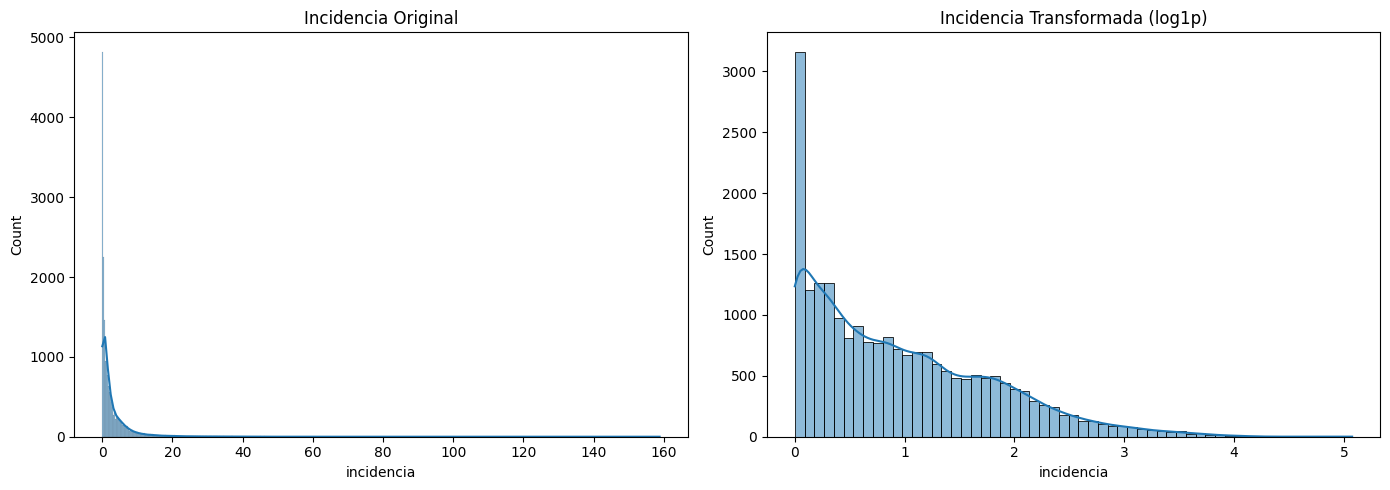

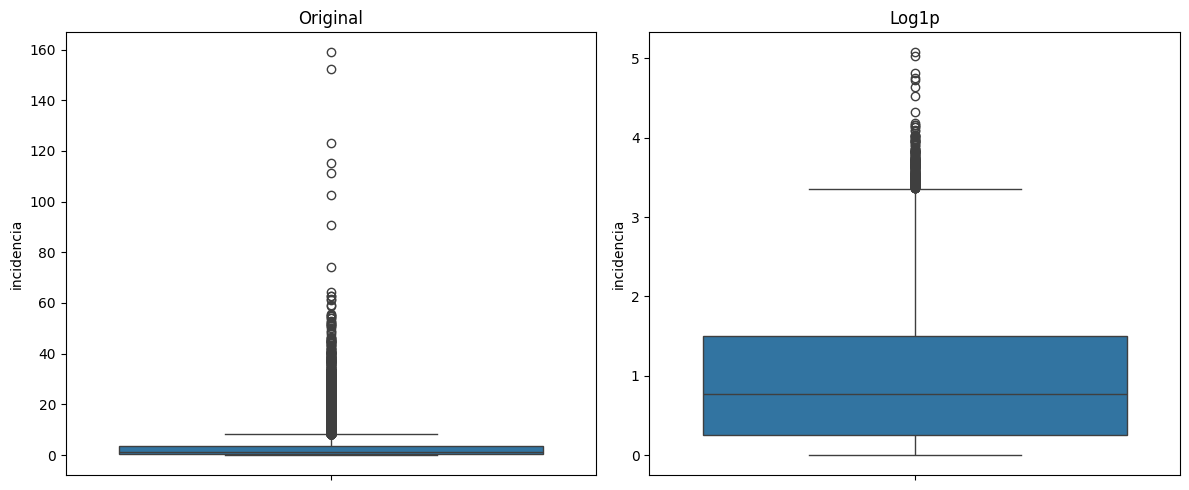

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df["incidencia"],
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Incidencia Original")

sns.histplot(
    np.log1p(df["incidencia"]),
    kde=True,
    ax=axes[1]
)
axes[1].set_title("Incidencia Transformada (log1p)")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df["incidencia"], ax=axes[0])
axes[0].set_title("Original")

sns.boxplot(y=np.log1p(df["incidencia"]), ax=axes[1])
axes[1].set_title("Log1p")

plt.tight_layout()
plt.show()

In [13]:
NUM_NODES = df["departamento"].nunique()

### **4.3.3. Normalización de los Datos**

Se plantea la función `scale_data` con el fin de aplicar una **normalización robusta (RobustScaler)** a los datos de entrenamiento y validación, para así preservar la estructura original de series temporales multivariadas. Para ello, primero reestructura los tensores a dos dimensiones para ajustar el escalador únicamente sobre el conjunto de entrenamiento, evitando *data leakage*, y luego transforma ambos conjuntos antes de devolverlos a su forma original.

In [14]:
def scale_data(X_train, X_val):

    scaler = RobustScaler()

    _, _, _, n_features = X_train.shape

    X_train_2d = X_train.reshape(-1, n_features)

    scaler.fit(X_train_2d)

    X_train_scaled = scaler.transform(X_train_2d).reshape(X_train.shape)

    X_val_scaled = scaler.transform(
        X_val.reshape(-1, n_features)
    ).reshape(X_val.shape)

    return X_train_scaled, X_val_scaled, scaler

## **4.4. Esquema de validación temporal**

Se implementa un esquema de **validación cruzada temporal anidada (nested time series cross-validation)**, en el cual los datos se dividen respetando estrictamente el orden cronológico para evitar *data leakage*. En el nivel externo, se definen particiones de entrenamiento y prueba por año (2022–2024), simulando un escenario real de predicción futura; mientras que en el nivel interno, el conjunto de entrenamiento se subdivide nuevamente en conjuntos de entrenamiento y validación (2019–2021) para ajuste de hiperparámetros y selección de modelos. Este enfoque garantiza una evaluación más robusta y realista al emular la dinámica de predicción en series temporales.

In [15]:
def create_outer_folds(df, date_col="fecha_inicio"):

    folds       = []
    outer_years = [2022, 2023, 2024]

    for test_year in outer_years:

        train_df = df[df[date_col].dt.year <  test_year].copy()
        test_df  = df[df[date_col].dt.year == test_year].copy()

        folds.append({
            "test_year": test_year,
            "train_df":  train_df,
            "test_df":   test_df
        })

    return folds


outer_folds = create_outer_folds(df)

In [16]:
def create_inner_folds(train_df, val_years=[2019, 2020, 2021]):

    inner_folds = []

    for val_year in val_years:

        inner_train = train_df[
            train_df["fecha_inicio"].dt.year < val_year
        ].copy()

        inner_val = train_df[
            train_df["fecha_inicio"].dt.year == val_year
        ].copy()

        inner_folds.append({
            "val_year":    val_year,
            "inner_train": inner_train,
            "inner_val":   inner_val
        })

    return inner_folds

## **4.5. Construcción de Ventanas de Tiempo**

Esta función implementa la construcción del conjunto de datos supervisado para modelado espaciotemporal, mediante la transformación de datos tabulares en tensores estructurados compatibles con arquitecturas de aprendizaje profundo. En primer lugar, reorganiza las variables explicativas y la variable objetivo a través de tablas pivote indexadas por fecha y departamento, asegurando consistencia en la representación espacial. Posteriormente, se unifican las variables en un tensor multivariado y se genera una estructura de secuencias mediante una estrategia de ventanas deslizantes (*sliding window*), en la que se define explícitamente un historial de observación (`window_size`) y un horizonte de predicción (`horizon`). Finalmente, se preserva información auxiliar como las fechas de referencia y el orden de los departamentos, lo cual es fundamental para mantener la coherencia temporal y espacial del conjunto de datos.


In [ ]:
def create_windows(
    df,
    features,
    target,
    window_size=12,
    horizon=4
):

    pivot_features = []

    for feat in features:

        pivot = df.pivot_table(
            index="fecha_inicio",
            columns="departamento",
            values=feat
        ).sort_index()

        pivot_features.append(pivot)

    dept_order = pivot_features[0].columns.tolist()

    pivot_features = [
        pf[dept_order].values for pf in pivot_features
    ]

    X_all = np.stack(pivot_features, axis=-1)

    target_pivot = df.pivot_table(
        index="fecha_inicio",
        columns="departamento",
        values=target
    ).sort_index()

    target_pivot = target_pivot[dept_order]

    y_all = target_pivot.values
    dates = target_pivot.index.values

    X, y, base_dates = [], [], []

    total_steps = len(dates)

    for i in range(total_steps - window_size - horizon + 1):

        X.append(X_all[i : i + window_size])
        y.append(y_all[i + window_size : i + window_size + horizon])
        base_dates.append(dates[i + window_size - 1])

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)
    base_dates = np.array(base_dates)

    return X, y, base_dates, dept_order

## **4.6. Funciones para el Modelado**

La clase EarlyStopping introduce un mecanismo de regularización basado en la detención anticipada del entrenamiento cuando la pérdida de validación deja de mejorar durante un número determinado de épocas (patience), lo cual ayuda a prevenir sobreajuste.

In [18]:
class EarlyStopping:

    def __init__(self, patience=20):

        self.patience  = patience
        self.best_loss = np.inf
        self.counter   = 0
        self.stop      = False

    def step(self, val_loss):

        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


Por otro lado, train_one_epoch y validate_one_epoch definen los ciclos estándar de entrenamiento y evaluación por época, respectivamente: la primera realiza la optimización del modelo mediante retropropagación del error, actualización de parámetros y recorte de gradientes para estabilizar el aprendizaje, mientras que la segunda evalúa el desempeño del modelo en modo inferencia sin actualización de pesos, permitiendo monitorear su generalización.

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()
    total_loss = 0

    for X_batch, y_batch in dataloader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        pred = model(X_batch)

        loss = criterion(pred, y_batch)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


def validate_one_epoch(model, dataloader, criterion, device):

    model.eval()
    total_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in dataloader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(X_batch)

            loss = criterion(pred, y_batch)

            total_loss += loss.item()

    return total_loss / len(dataloader)

## **4.7. Arquitectura**

Esta sección define la **arquitectura del modelo LSTM y la estructura del dataset utilizada para su entrenamiento** en un contexto espaciotemporal. La clase `Dataset` convierte los datos preprocesados en tensores compatibles con PyTorch, facilitando su uso en el pipeline de entrenamiento. Por su parte, la clase `LSTM` implementa una red neuronal recurrente que recibe como entrada secuencias multivariadas organizadas por nodos espaciales y variables, las reestructura en una secuencia temporal plana y las procesa mediante capas LSTM. Finalmente, una red *fully connected* transforma la representación latente en predicciones multi-horizonte, generando salidas simultáneas para todos los nodos del sistema.

In [ ]:
class Dataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [ ]:
class LSTM(nn.Module):

    def __init__(
        self,
        num_nodes,
        in_channels,
        hidden_size=64,
        num_layers=2,
        horizon=4,
        dropout=0.1
    ):
        super().__init__()

        self.num_nodes = num_nodes
        self.horizon = horizon
        self.hidden_size = hidden_size

        self.lstm = nn.LSTM(
            input_size=num_nodes * in_channels,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, horizon * num_nodes)
        )

    def forward(self, x, adj=None):

        batch, T, nodes, feats = x.shape

        x = x.reshape(batch, T, nodes * feats)

        out, _ = self.lstm(x)         

        last = out[:, -1, :]          

        last = self.dropout(last)

        out = self.fc(last)           

        out = out.reshape(batch, self.horizon, self.num_nodes)

        return out

## **4.8. Optimización de Hiperparametros**

Inicializamos el entorno experimental del pipeline de optimización y evaluación del modelo,  definiendo estructuras globales para almacenar resultados de múltiples etapas del experimento (tuning, validación cruzada, entrenamiento y evaluación final).

In [22]:
ALL_OPTUNA_TRIALS = []
ALL_OPTUNA_FOLDS = []
ALL_RESIDUALS = []
ALL_INFERENCE_TIME = []
ALL_BEST_PARAMS = []
ALL_RESULTS     = []
ALL_PREDICTIONS = []
ALL_LOSSES      = []

TUNING_DF = df[df["fecha_inicio"].dt.year < 2022].copy()

INNER_FOLDS_TUNING = create_inner_folds(
    TUNING_DF,
    val_years=[2019, 2020, 2021]
)


Ahora, definimos **objetivo de optimización para el ajuste de hiperparámetros mediante Optuna**, evaluando distintas configuraciones del modelo LSTM. Para cada *trial*, se muestrean hiperparámetros como tamaño de ventana, tasa de aprendizaje, tamaño de lote, número de capas, unidades ocultas y *dropout*, y se evalúan mediante validación cruzada en los *inner folds*. En cada partición se entrena el modelo, se aplica *early stopping* y se calcula el RMSE sobre el conjunto de validación, retornando finalmente el error promedio como métrica a minimizar.

In [ ]:
def objective(trial):

    window_size = trial.suggest_categorical("window_size", [4, 8, 12, 16])
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32])
    hidden_size = trial.suggest_categorical("hidden_size", [32, 64, 128])
    num_layers = trial.suggest_int("num_layers", 1, 3)
    dropout = trial.suggest_float("dropout", 0.0, 0.4, step=0.1)

    rmse_folds = []
    fold_errors = []

    for fold_id, fold in enumerate(INNER_FOLDS_TUNING):

        X_train, y_train, _, _ = create_windows(
            fold["inner_train"], FEATURES, TARGET, window_size, 4
        )

        X_val, y_val, _, _ = create_windows(
            fold["inner_val"], FEATURES, TARGET, window_size, 4
        )

        X_train_scaled, X_val_scaled, _ = scale_data(X_train, X_val)

        train_loader = DataLoader(
            Dataset(X_train_scaled, y_train),
            batch_size=batch_size,
            shuffle=False
        )

        val_loader = DataLoader(
            Dataset(X_val_scaled, y_val),
            batch_size=batch_size,
            shuffle=False
        )

        model = LSTM(
            num_nodes=NUM_NODES,
            in_channels=len(FEATURES),
            hidden_size=hidden_size,
            num_layers=num_layers,
            horizon=4,
            dropout=dropout
        ).to(DEVICE)

        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        criterion = nn.MSELoss()

        early_stopping = EarlyStopping(patience=10)

        for epoch in range(50):

            train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
            val_loss = validate_one_epoch(model, val_loader, criterion, DEVICE)

            early_stopping.step(val_loss)

            if early_stopping.stop:
                break

        # eval
        model.eval()

        preds, trues = [], []

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                pred = model(X_batch.to(DEVICE))

                preds.append(pred.cpu().numpy())
                trues.append(y_batch.numpy())

        preds = np.concatenate(preds)
        trues = np.concatenate(trues)

        rmse = np.sqrt(mean_squared_error(trues.flatten(), preds.flatten()))

        rmse_folds.append(rmse)

        fold_errors.append({
            "trial": trial.number,
            "seed": seed,
            "fold": fold_id,
            "rmse": rmse
        })

    rmse_mean = np.mean(rmse_folds)

    return rmse_mean

## **4.9. Pipeline Train, Validation & Test**

Ahora se procede a ejecutar el ciclo completo de entrenamiento, optimización y evaluación del modelo LSTM bajo un esquema de validación cruzada temporal anidada. En este proceso, se realiza la búsqueda de hiperparámetros mediante Optuna para cada semilla, seguida del entrenamiento del modelo en los *outer folds* utilizando la mejor configuración obtenida. Finalmente, se evalúa el desempeño en el conjunto de prueba mediante métricas de error, registrando adicionalmente tiempos de entrenamiento e inferencia, así como predicciones y residuos para su análisis detallado posterior.

In [ ]:
for seed in SEEDS:

    print("\n")
    print("="*100)
    print(f"SEED {seed}")
    print("="*100)

    set_seed(seed)

    sampler = optuna.samplers.TPESampler(seed=seed)

    study = optuna.create_study(
        direction="minimize",
        sampler=sampler
    )

    study.optimize(objective, n_trials=30)

    best_params = study.best_trial.params

    print(f"\nMejores hiperparámetros para seed {seed}:")
    print(best_params)

    pd.DataFrame([{"seed": seed, **best_params}]).to_csv(
        f"/home/guirlessa/Dl_Proyecto_Dengue/Modelos/LSTM/LSTM_best_params_seed_{seed}.csv",
        index=False
    )

    ALL_BEST_PARAMS.append({"seed": seed, **best_params})

    for outer_idx, outer_fold in enumerate(outer_folds):

        print("\n")
        print("="*100)
        print(f"OUTER FOLD {outer_idx+1} | Test year: {outer_fold['test_year']}")
        print("="*100)

        outer_train_df = outer_fold["train_df"]
        final_test_df  = outer_fold["test_df"]

        window_size   = best_params["window_size"]
        hidden_size   = best_params["hidden_size"]
        num_layers    = best_params["num_layers"]
        dropout       = best_params["dropout"]
        learning_rate = best_params["learning_rate"]
        batch_size    = best_params["batch_size"]

        val_year = outer_train_df["fecha_inicio"].dt.year.max()

        final_train_df = outer_train_df[
            outer_train_df["fecha_inicio"].dt.year < val_year
        ]

        final_val_df = outer_train_df[
            outer_train_df["fecha_inicio"].dt.year == val_year
        ]

        X_train, y_train, train_dates, dept_order = create_windows(
            final_train_df, FEATURES, TARGET, window_size, 4
        )
        
        idx_to_dept = {i: d for i, d in enumerate(dept_order)}
        dept_to_idx = {d: i for i, d in enumerate(dept_order)}

        X_val, y_val, val_dates, _ = create_windows(
            final_val_df, FEATURES, TARGET, window_size, 4
        )

        X_test, y_test, test_dates, _ = create_windows(
            final_test_df, FEATURES, TARGET, window_size, 4
        )

        X_train_scaled, X_val_scaled, scaler = scale_data(X_train, X_val)

        X_test_scaled = scaler.transform(
            X_test.reshape(-1, X_test.shape[-1])
        ).reshape(X_test.shape)

        train_dataset = Dataset(X_train_scaled, y_train)
        val_dataset   = Dataset(X_val_scaled,   y_val)
        test_dataset  = Dataset(X_test_scaled,  y_test)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
        val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
        test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

        model = LSTM(
            num_nodes=NUM_NODES,
            in_channels=len(FEATURES),
            hidden_size=hidden_size,
            num_layers=num_layers,
            horizon=4,
            dropout=dropout
        ).to(DEVICE)

        criterion = nn.MSELoss()

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=10
        )

        early_stopping = EarlyStopping(patience=20)

        best_model = None
        best_loss = np.inf

        total_train_time = 0.0

        for epoch in range(300):

            start_epoch = time.time()

            train_loss = train_one_epoch(
                model, train_loader, criterion, optimizer, DEVICE
            )

            val_loss = validate_one_epoch(
                model, val_loader, criterion, DEVICE
            )

            scheduler.step(val_loss)

            epoch_time = time.time() - start_epoch
            total_train_time += epoch_time

            print(
                f"Epoch {epoch+1}"
                f" | Train {train_loss:.4f}"
                f" | Val {val_loss:.4f}"
                f" | Time {epoch_time:.2f}s"
            )

            ALL_LOSSES.append({
                "seed": seed,
                "outer_fold": outer_idx + 1,
                "test_year": outer_fold["test_year"],
                "epoch": epoch + 1,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "epoch_time": epoch_time
            })

            if val_loss < best_loss:
                best_loss = val_loss
                best_model = copy.deepcopy(model)

            early_stopping.step(val_loss)

            if early_stopping.stop:
                break

        model = best_model

        torch.save(
            model.state_dict(),
            f"/home/guirlessa/Dl_Proyecto_Dengue/Modelos/LSTM/"
            f"lstm_seed_{seed}_outer_fold_{outer_idx+1}.pt"
        )

        model.eval()

        start_inference = time.time()

        predictions = []
        targets = []

        with torch.no_grad():
            for X_batch, y_batch in test_loader:

                X_batch = X_batch.to(DEVICE)

                pred = model(X_batch.to(DEVICE))

                predictions.append(pred.cpu().numpy())
                targets.append(y_batch.numpy())

        inference_time = time.time() - start_inference

        predictions = np.concatenate(predictions)
        targets     = np.concatenate(targets)

        mse  = mean_squared_error(targets.flatten(), predictions.flatten())
        rmse = np.sqrt(mse)
        mae  = mean_absolute_error(targets.flatten(), predictions.flatten())
        r2   = r2_score(targets.flatten(), predictions.flatten())

        ALL_RESULTS.append({
            "seed": seed,
            "outer_fold": outer_idx + 1,
            "test_year": outer_fold["test_year"],
            "mse": mse,
            "rmse": rmse,
            "mae": mae,
            "r2": r2,
            "train_time": total_train_time,
            "inference_time": inference_time
        })

        ALL_INFERENCE_TIME.append({
            "seed": seed,
            "outer_fold": outer_idx + 1,
            "test_year": outer_fold["test_year"],
            "inference_time": inference_time,
            "train_time": total_train_time
        })


        rows = []

        for i in range(len(predictions)):
            for h in range(4):
                for node in range(NUM_NODES):

                    y_true = targets[i, h, node]
                    y_pred = predictions[i, h, node]

                    residual = y_true - y_pred

                    rows.append({
                        "seed": seed,
                        "outer_fold": outer_idx + 1,
                        "test_year": outer_fold["test_year"],
                        "departamento": idx_to_dept[node],
                        "fecha_base": test_dates[i],
                        "horizonte": h + 1,

                        "y_true_log": y_true,
                        "y_pred_log": y_pred,

                        "y_true_real": np.expm1(y_true),
                        "y_pred_real": np.expm1(y_pred),

                        "residual": residual,
                        "abs_error": abs(residual),
                        "sq_error": residual ** 2
                    })

                    ALL_RESIDUALS.append({
                        "seed": seed,
                        "outer_fold": outer_idx + 1,
                        "test_year": outer_fold["test_year"],
                        "departamento": idx_to_dept[node],
                        "fecha_base": test_dates[i],
                        "horizonte": h + 1,
                        "residual": residual
                    })

        ALL_PREDICTIONS.append(pd.DataFrame(rows))

[I 2026-06-01 13:34:49,783] A new study created in memory with name: no-name-ed3bac65-25f4-4b96-b951-3c587e55607f




SEED 42
Seed fijada: 42


[I 2026-06-01 13:35:04,674] Trial 0 finished with value: 0.6980026211034188 and parameters: {'window_size': 8, 'learning_rate': 0.0002051338263087451, 'batch_size': 16, 'hidden_size': 32, 'num_layers': 1, 'dropout': 0.4}. Best is trial 0 with value: 0.6980026211034188.
[I 2026-06-01 13:35:14,830] Trial 1 finished with value: 0.6753492616054756 and parameters: {'window_size': 4, 'learning_rate': 0.0004059611610484307, 'batch_size': 16, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.1}. Best is trial 1 with value: 0.6753492616054756.
[I 2026-06-01 13:35:19,599] Trial 2 finished with value: 0.6916170885484471 and parameters: {'window_size': 8, 'learning_rate': 0.0015304852121831463, 'batch_size': 32, 'hidden_size': 128, 'num_layers': 3, 'dropout': 0.4}. Best is trial 1 with value: 0.6753492616054756.
[I 2026-06-01 13:35:34,417] Trial 3 finished with value: 0.6922186615875142 and parameters: {'window_size': 12, 'learning_rate': 0.00017541893487450815, 'batch_size': 16, 'hidden_size': 32,


Mejores hiperparámetros para seed 42:
{'window_size': 8, 'learning_rate': 0.0006439776873611326, 'batch_size': 32, 'hidden_size': 128, 'num_layers': 1, 'dropout': 0.2}


OUTER FOLD 1 | Test year: 2022
Epoch 1 | Train 0.9460 | Val 0.5891 | Time 0.05s
Epoch 2 | Train 0.4987 | Val 0.4799 | Time 0.06s
Epoch 3 | Train 0.3233 | Val 0.4643 | Time 0.05s
Epoch 4 | Train 0.2928 | Val 0.4487 | Time 0.05s
Epoch 5 | Train 0.2743 | Val 0.4228 | Time 0.05s
Epoch 6 | Train 0.2571 | Val 0.4092 | Time 0.05s
Epoch 7 | Train 0.2404 | Val 0.3877 | Time 0.06s
Epoch 8 | Train 0.2331 | Val 0.3707 | Time 0.05s
Epoch 9 | Train 0.2149 | Val 0.3888 | Time 0.07s
Epoch 10 | Train 0.2049 | Val 0.3774 | Time 0.06s
Epoch 11 | Train 0.2230 | Val 0.3804 | Time 0.06s
Epoch 12 | Train 0.1952 | Val 0.3557 | Time 0.06s
Epoch 13 | Train 0.1872 | Val 0.3840 | Time 0.07s
Epoch 14 | Train 0.1759 | Val 0.3476 | Time 0.06s
Epoch 15 | Train 0.1614 | Val 0.3543 | Time 0.05s
Epoch 16 | Train 0.1490 | Val 0.3679 | Time 0.05s
Epoch 1

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(


...

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(


Epoch 1 | Train 0.8793 | Val 0.6432 | Time 0.08s
Epoch 2 | Train 0.5126 | Val 0.7581 | Time 0.08s
Epoch 3 | Train 0.4170 | Val 0.5639 | Time 0.07s
Epoch 4 | Train 0.3505 | Val 0.5214 | Time 0.07s
Epoch 5 | Train 0.3451 | Val 0.5367 | Time 0.08s
Epoch 6 | Train 0.3323 | Val 0.5453 | Time 0.07s
Epoch 7 | Train 0.3285 | Val 0.5380 | Time 0.08s
Epoch 8 | Train 0.3225 | Val 0.5421 | Time 0.08s
Epoch 9 | Train 0.3276 | Val 0.5203 | Time 0.08s
Epoch 10 | Train 0.3237 | Val 0.5745 | Time 0.08s
Epoch 11 | Train 0.3133 | Val 0.5626 | Time 0.08s
Epoch 12 | Train 0.3193 | Val 0.5194 | Time 0.07s
Epoch 13 | Train 0.3101 | Val 0.4627 | Time 0.07s
Epoch 14 | Train 0.3287 | Val 0.5446 | Time 0.07s
Epoch 15 | Train 0.2916 | Val 0.5083 | Time 0.07s
Epoch 16 | Train 0.2682 | Val 0.4526 | Time 0.07s
Epoch 17 | Train 0.2691 | Val 0.4695 | Time 0.09s
Epoch 18 | Train 0.2659 | Val 0.4482 | Time 0.08s
Epoch 19 | Train 0.2566 | Val 0.4495 | Time 0.08s
Epoch 20 | Train 0.2640 | Val 0.5047 | Time 0.07s
Epoch 21 

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(


Epoch 1 | Train 0.8551 | Val 0.8937 | Time 0.08s
Epoch 2 | Train 0.5440 | Val 1.3662 | Time 0.08s
Epoch 3 | Train 0.4565 | Val 0.7693 | Time 0.08s
Epoch 4 | Train 0.3816 | Val 0.6866 | Time 0.08s
Epoch 5 | Train 0.3813 | Val 0.6140 | Time 0.08s
Epoch 6 | Train 0.3953 | Val 0.7755 | Time 0.08s
Epoch 7 | Train 0.3585 | Val 0.6750 | Time 0.08s
Epoch 8 | Train 0.3552 | Val 0.6160 | Time 0.07s
Epoch 9 | Train 0.3579 | Val 0.6261 | Time 0.08s
Epoch 10 | Train 0.3439 | Val 0.6283 | Time 0.08s
Epoch 11 | Train 0.3315 | Val 0.6583 | Time 0.08s
Epoch 12 | Train 0.3350 | Val 0.5824 | Time 0.11s
Epoch 13 | Train 0.3412 | Val 0.5894 | Time 0.08s
Epoch 14 | Train 0.3475 | Val 0.6352 | Time 0.08s
Epoch 15 | Train 0.3266 | Val 0.7015 | Time 0.09s
Epoch 16 | Train 0.3293 | Val 0.7940 | Time 0.09s
Epoch 17 | Train 0.3219 | Val 0.6455 | Time 0.08s
Epoch 18 | Train 0.3154 | Val 0.5949 | Time 0.09s
Epoch 19 | Train 0.3177 | Val 0.6706 | Time 0.09s
Epoch 20 | Train 0.2855 | Val 0.8229 | Time 0.09s
Epoch 21 

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(


In [ ]:
results_df        = pd.DataFrame(ALL_RESULTS)
predictions_df    = pd.concat(ALL_PREDICTIONS, axis=0)
losses_df         = pd.DataFrame(ALL_LOSSES)
best_params_df    = pd.DataFrame(ALL_BEST_PARAMS)

optuna_trials_df  = pd.DataFrame(ALL_OPTUNA_TRIALS)
optuna_folds_df   = pd.DataFrame(ALL_OPTUNA_FOLDS)

inference_df      = pd.DataFrame(ALL_INFERENCE_TIME)
residuals_df      = pd.DataFrame(ALL_RESIDUALS)

BASE_PATH = "/home/guirlessa/Dl_Proyecto_Dengue/Modelos/LSTM"

results_df.to_csv(f"{BASE_PATH}/lstm_results.csv", index=False)

predictions_df.to_csv(
    f"{BASE_PATH}/lstm_predictions.csv",
    index=False
)

losses_df.to_csv(
    f"{BASE_PATH}/lstm_training_history.csv",
    index=False
)

best_params_df.to_csv(
    f"{BASE_PATH}/lstm_best_params.csv",
    index=False
)


optuna_trials_df.to_csv(
    f"{BASE_PATH}/lstm_optuna_trials.csv",
    index=False
)

optuna_folds_df.to_csv(
    f"{BASE_PATH}/lstm_optuna_folds.csv",
    index=False
)


inference_df.to_csv(
    f"{BASE_PATH}/lstm_inference_time.csv",
    index=False
)


residuals_df.to_csv(
    f"{BASE_PATH}/lstm_residuals.csv",
    index=False
)

print("\n" + "="*100)
print("FINAL RESULTS")
print("="*100)

print(results_df.describe())

## **4.10. Evaluando el Modelo**

In [24]:
MODEL_NAME = "LSTM"
BASE_PATH = "Modelos/LSTM"

results = pd.read_csv(f"{BASE_PATH}/lstm_results.csv")
preds = pd.read_csv(f"{BASE_PATH}/lstm_predictions.csv")
residuals = pd.read_csv(f"{BASE_PATH}/lstm_residuals.csv")
history = pd.read_csv(f"{BASE_PATH}/lstm_training_history.csv")

In [25]:
def compute_metrics(df, col_true='y_true_real', col_pred='y_pred_real', col_seed='seed'):
    metrics = []
    for seed in df[col_seed].unique():
        subset = df[df[col_seed] == seed]

        rmse = np.sqrt(mean_squared_error(subset[col_true], subset[col_pred]))
        mae = mean_absolute_error(subset[col_true], subset[col_pred])
        r2 = r2_score(subset[col_true], subset[col_pred])

        metrics.append({
            'seed': seed,
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2
        })

    return pd.DataFrame(metrics)


metrics_real = compute_metrics(preds)

print(metrics_real)

metrics_real.to_csv(f"{BASE_PATH}/metrics_lstm.csv", index=False)

   seed      RMSE       MAE        R2
0    42  7.643459  4.205040  0.048068
1   123  7.069677  3.966179  0.002728
2  2024  7.050868  3.969128  0.008028


Los resultados muestran un comportamiento consistente en las métricas de error, con valores de RMSE cercanos a 7 y MAE alrededor de 4, lo que indica una variabilidad moderada en las predicciones. Sin embargo, el coeficiente de determinación (R²) se mantiene cercano a cero en todas las semillas, lo que sugiere una capacidad explicativa limitada del modelo sobre la variabilidad de los datos en el conjunto de prueba.

In [26]:
summary_real = metrics_real[['RMSE','MAE','R2']].agg(['mean','std'])

print("\nResumen LSTM:\n", summary_real)


Resumen LSTM:
           RMSE       MAE        R2
mean  7.254668  4.046782  0.019608
std   0.336835  0.137063  0.024789


El resumen global del desempeño del modelo LSTM a través de las distintas semillas evaluadas muestra que, en promedio, el modelo alcanza un RMSE de 7.25 y un MAE de 4.05, con una baja desviación estándar, lo que indica estabilidad en los errores de predicción. No obstante, el valor medio de R² (0.02) refleja un poder explicativo muy limitado, sugiriendo que el modelo captura parcialmente la dinámica de la serie, pero aún no logra explicar de forma significativa la variabilidad observada en los datos.


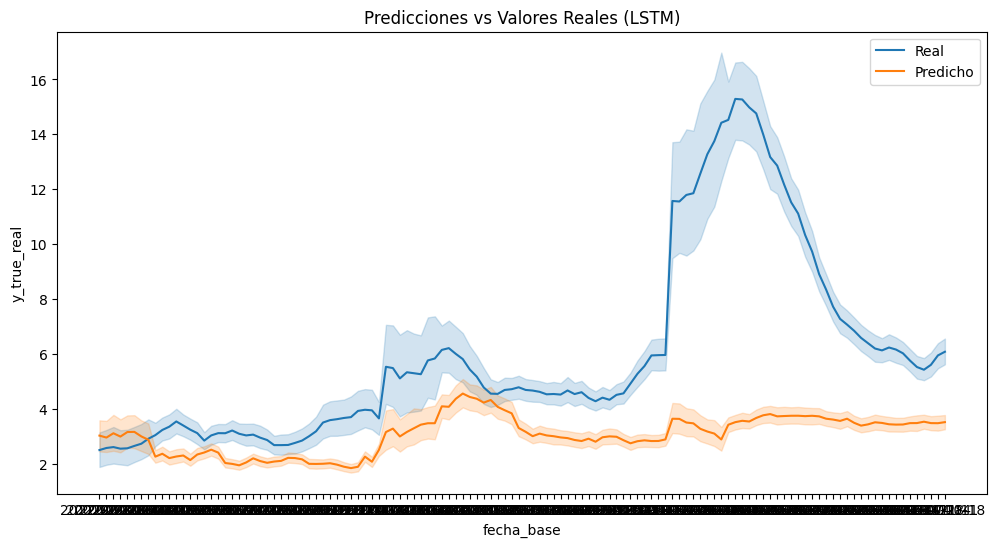

In [27]:
plt.figure(figsize=(12,6))
sns.lineplot(x='fecha_base', y='y_true_real', data=preds, label='Real')
sns.lineplot(x='fecha_base', y='y_pred_real', data=preds, label='Predicho')
plt.title("Predicciones vs Valores Reales (LSTM)")
plt.legend()
plt.show()

El gráfico muestra que el modelo LSTM logra capturar parcialmente la tendencia general de los valores reales de dengue, pero subestima de forma considerable los picos epidémicos. La serie azul (valores reales) presenta aumentos pronunciados en ciertos periodos, mientras que la serie naranja (predicciones) mantiene una evolución más suavizada y con menor amplitud. Esto sugiere que el modelo reproduce bien las fases de baja incidencia y las transiciones graduales, pero tiene dificultades para representar los incrementos abruptos asociados a brotes intensos.

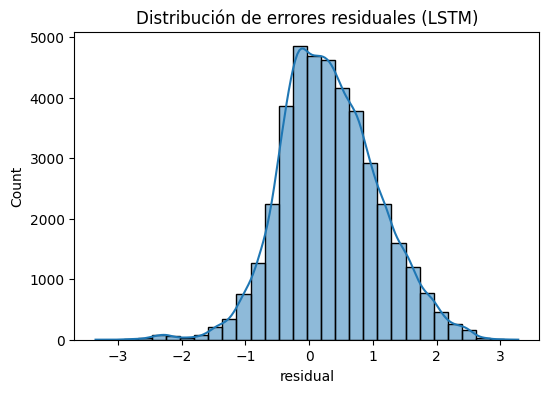

In [28]:
plt.figure(figsize=(6,4))
sns.histplot(residuals['residual'], bins=30, kde=True)
plt.title("Distribución de errores residuales (LSTM)")
plt.show()

El histograma de errores residuales del modelo LSTM muestra una distribución aproximadamente normal, centrada en cero, lo que indica que el modelo no presenta sesgos sistemáticos hacia la sobreestimación o subestimación de los valores reales. La mayoría de los residuos se concentran cerca de cero, reflejando que las predicciones tienden a ser precisas en promedio, mientras que los errores grandes son poco frecuentes. Esta forma simétrica y con colas moderadas sugiere que el modelo captura adecuadamente la estructura temporal de los datos y que los errores se comportan como ruido aleatorio, una señal positiva de buen ajuste y estabilidad en la estimación.

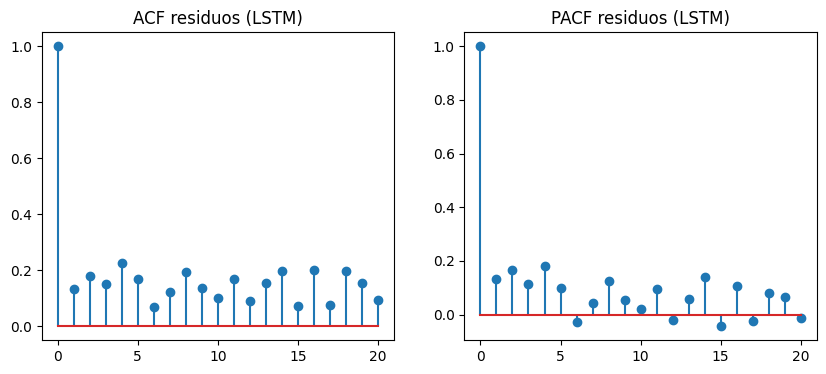

In [29]:
acf_vals = acf(residuals['residual'], nlags=20)
pacf_vals = pacf(residuals['residual'], nlags=20)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.stem(acf_vals)
plt.title("ACF residuos (LSTM)")

plt.subplot(1,2,2)
plt.stem(pacf_vals)
plt.title("PACF residuos (LSTM)")

plt.show()

En ambos se aprecia que, salvo el valor esperado en el rezago cero, las autocorrelaciones para los rezagos siguientes son bajas y no muestran patrones significativos. Esto indica que los residuos del modelo LSTM se comportan como ruido blanco, es decir, no presentan dependencia temporal.

In [30]:
lb = acorr_ljungbox(residuals['residual'], lags=[10, 20], return_df=True)
print(lb)

         lb_stat  lb_pvalue
10   9757.501584        0.0
20  18863.822787        0.0


Los resultados del test de Ljung-Box (lb_stat ≈ 9757.5 y 18863.8 con p‑valor = 0.0) indican que los residuos del modelo LSTM **no son completamente independientes**, es decir, aún existe autocorrelación significativa en los rezagos analizados. Esto contrasta con lo observado en los gráficos de ACF y PACF, donde las correlaciones parecían bajas. La discrepancia se debe a que el test es más sensible estadísticamente y detecta dependencias pequeñas pero sistemáticas que visualmente pueden pasar desapercibidas. En conjunto, el modelo logra capturar la estructura principal de la serie, pero los residuos conservan cierta memoria temporal.

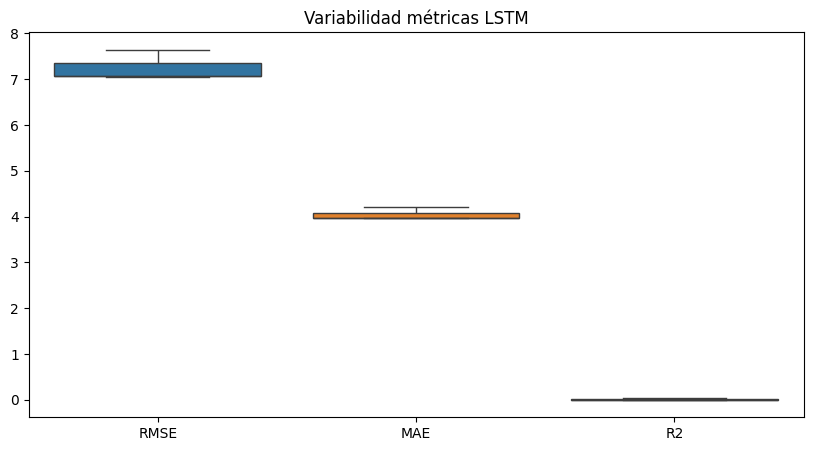

In [31]:
plt.figure(figsize=(10,5))
sns.boxplot(data=metrics_real[['RMSE','MAE','R2']])
plt.title("Variabilidad métricas LSTM")
plt.show()

El gráfico de caja muestra que el modelo LSTM mantiene una **variabilidad muy baja en sus métricas**, lo que refleja estabilidad en el desempeño entre diferentes ejecuciones o particiones de datos. El **RMSE** se concentra alrededor de 7.2, indicando un error promedio moderado en la escala de los valores reales; el **MAE**, cercano a 4, confirma una desviación media relativamente constante; y el **R²**, próximo a 0, sugiere una capacidad limitada para explicar la varianza total del fenómeno. En conjunto, el modelo es consistente pero poco explicativo: reproduce patrones generales sin grandes fluctuaciones en precisión, aunque su poder predictivo sigue siendo bajo.

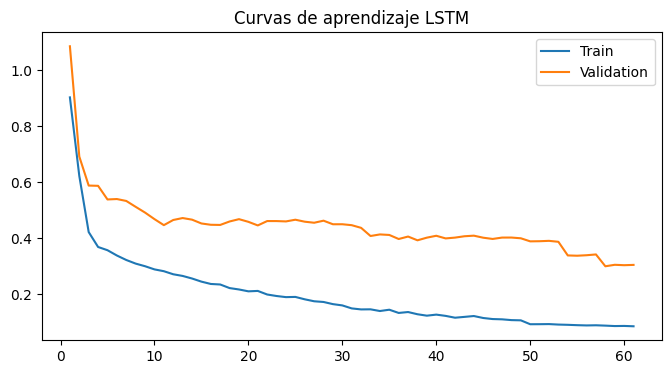

In [32]:
avg_history = history.groupby('epoch')[['train_loss','val_loss']].mean().reset_index()

plt.figure(figsize=(8,4))
plt.plot(avg_history['epoch'], avg_history['train_loss'], label='Train')
plt.plot(avg_history['epoch'], avg_history['val_loss'], label='Validation')
plt.title("Curvas de aprendizaje LSTM")
plt.legend()
plt.show()

Las curvas de aprendizaje del modelo LSTM muestran un comportamiento donde se aprecia un **entrenamiento estable y sin sobreajuste severo**. La pérdida de entrenamiento (línea azul) desciende de manera continua hasta valores muy bajos, lo que indica que el modelo aprende progresivamente los patrones de la serie temporal. La pérdida de validación (línea naranja) también disminuye al inicio y luego se estabiliza alrededor de 0.3–0.4, manteniéndose por encima de la curva de entrenamiento. Esta brecha sugiere una ligera diferencia entre el rendimiento en entrenamiento y validación, pero sin divergencia marcada, lo que implica buena generalización. En conjunto, el modelo logra convergencia adecuada y evita el sobreentrenamiento.

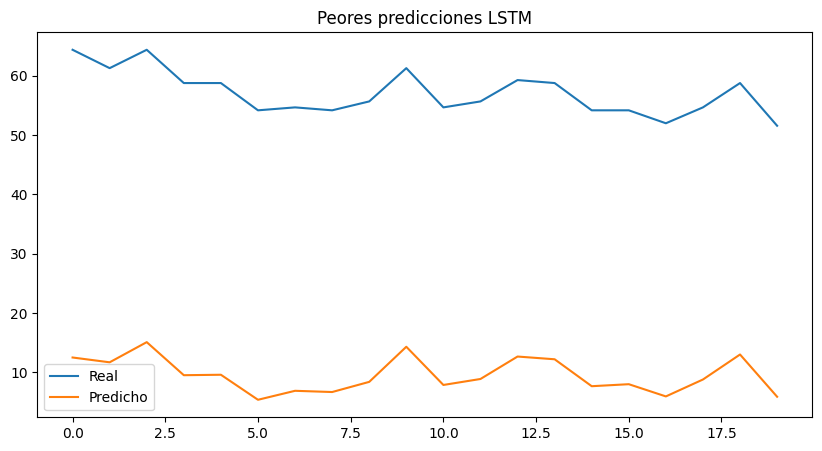

In [33]:
worst = preds.copy()
worst['error'] = abs(worst['y_true_real'] - worst['y_pred_real'])

worst_cases = worst.sort_values('error', ascending=False).head(20)

plt.figure(figsize=(10,5))
plt.plot(worst_cases['y_true_real'].values, label='Real')
plt.plot(worst_cases['y_pred_real'].values, label='Predicho')
plt.title("Peores predicciones LSTM")
plt.legend()
plt.show()

El gráfico de las **peores predicciones del LSTM** evidencia que el modelo tiene dificultades para estimar correctamente los valores en los casos de mayor magnitud. Podemos observar que los valores reales se mantiene en niveles altos, alrededor de 55–65, mientras que las predicciones permanecen muy por debajo, entre 5 y 15. Esta brecha muestra una **subestimación sistemática** en los episodios más extremos, lo que sugiere que el modelo no logra capturar adecuadamente la dinámica de los picos epidémicos o valores fuera del rango habitual. En conjunto con los resultados previos, esto confirma que el LSTM reproduce bien las tendencias generales pero pierde precisión ante variaciones abruptas, indicando la necesidad de ajustar su arquitectura o incluir variables que representen mejor los factores que impulsan los brotes intensos.

In [34]:
def mean_ci(series):
    mean = np.mean(series)
    sem = st.sem(series)
    ci = st.t.interval(0.95, len(series)-1, loc=mean, scale=sem)
    return mean, ci
import scipy.stats as st

rmse_mean, rmse_ci = mean_ci(metrics_real['RMSE'])
mae_mean, mae_ci = mean_ci(metrics_real['MAE'])
r2_mean, r2_ci = mean_ci(metrics_real['R2'])

print("RMSE:", rmse_mean, rmse_ci)
print("MAE:", mae_mean, mae_ci)
print("R2:", r2_mean, r2_ci)

RMSE: 7.254667994641687 (np.float64(6.417924613495562), np.float64(8.09141137578781))
MAE: 4.046782111274713 (np.float64(3.7062988793778815), np.float64(4.387265343171546))
R2: 0.01960802789959104 (np.float64(-0.04197138607375059), np.float64(0.08118744187293267))


Los resultados cuantitativos del modelo LSTM confirman lo observado en los gráficos anteriores. El **RMSE = 7.25** y el **MAE = 4.05** indican errores moderados, consistentes con la subestimación de los picos epidémicos vista en las predicciones. El **R² ≈ 0.02**, con un intervalo de confianza que incluye valores negativos, revela una capacidad explicativa muy baja: el modelo apenas logra representar la variabilidad real de los datos. Aunque los intervalos de confianza son estrechos, lo que refleja estabilidad entre ejecuciones, el desempeño general sugiere que el LSTM captura tendencias básicas pero no las magnitudes extremas. En conjunto, el modelo es estable pero poco preciso, y requeriría ajustes en arquitectura o incorporación de variables exógenas para mejorar su poder predictivo y la sensibilidad ante brotes intensos.